# OceanoIA — 03_RNN_Oceanografia
# Predicción Oceanográfica: Exploración del Modelo y Resultados

Este notebook contiene:
- Los pasos del pipeline
- Entrena los 3 modelos (oleaje, marea, SST)
- Visualiza predicciones y compara metricas


## 1. Importar el modulo de entrenamiento

Se importa el modulo desde train que guarda el entrenamiento de este y muestra las funciones que estan disponibles


In [4]:
import sys
import os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rnn

print("Funciones disponibles en rnn.py:")
print([f for f in dir(rnn) if not f.startswith('_')])


Funciones disponibles en train.py:
['Dense', 'Dropout', 'EarlyStopping', 'FEATURES_DISPONIBLES', 'LSTM', 'MinMaxScaler', 'RUTA_BASE', 'RUTA_DATOS', 'RUTA_MODELOS', 'Sequential', 'argparse', 'cargar_datos', 'construir_modelo', 'crear_secuencias', 'desescalar_target', 'entrenar', 'evaluar', 'joblib', 'mean_absolute_error', 'mean_squared_error', 'np', 'os', 'parse_args', 'pd', 'preparar_features', 'tf']


## 2. Cargar y revisar los datos

Aqui se reutiliza `rnn.cargar_datos()` y `rnn.preparar_features()`  para garantizar que
estamos viendo exactamente los mismos datos que se le dan al modelo porque las
mismas funciones que usa el entrenamiento real,


In [5]:
df = rnn.cargar_datos()
df, features = rnn.preparar_features(df)

print('Filas:', df.shape[0], '| Columnas:', df.shape[1])
print('Rango de fechas:', df.index.min().date(), '->', df.index.max().date())
print('Features disponibles para el modelo:', features)
df[features].head()


Filas: 517 | Columnas: 12
Rango de fechas: 2025-01-01 -> 2026-06-01
Features disponibles para el modelo: ['Oleaje_m', 'Periodo_Oleaje_s', 'Direccion_Oleaje_deg', 'Marea_m', 'SST_Copernicus', 'temp_aire_c', 'viento_kmh', 'presion_hpa', 'humedad_pct', 'nubosidad_octas']


,Oleaje_m,Periodo_Oleaje_s,Direccion_Oleaje_deg,Marea_m,SST_Copernicus,temp_aire_c,viento_kmh,presion_hpa,humedad_pct,nubosidad_octas
Fecha,,,,,,,,,,
2025-01-01,0.376667,8.060417,190.000000,0.334583,27.862621,22.6,11.2,1009.6,72.0,6.0
2025-01-02,0.352500,10.320833,192.291667,0.337500,28.053205,22.6,12.7,1010.6,71.0,6.0
2025-01-03,0.405833,11.954167,191.625000,0.359583,27.944519,22.6,11.9,1010.7,70.0,5.0
2025-01-04,0.436667,10.829167,188.833333,0.394583,27.935103,22.6,11.5,1010.6,71.0,6.0
2025-01-05,0.407500,10.129167,187.166667,0.409583,28.068752,22.8,11.7,1010.4,73.0,5.0


## 3. Configuración

La ventana (`WINDOW_IN`/`WINDOW_OUT`) y la arquitectura estan como
valores por defecto en `rnn.py` `window_in=30` y `window_out=3`esto es
equivalente a 72 horas con datos diarios.


Aquí solo se muestran



In [6]:
print("Ventana de entrada dias historicos:", 30)
print("Horizonte de prediccion dias, ~72h:", 3)
print("Arquitectura: LSTM(100) -> LSTM(50) -> Dropout(0.2) -> Dense(3)")


Ventana de entrada (días de historia): 30
Horizonte de pronóstico (días, ~72h): 3
Arquitectura: LSTM(100) -> LSTM(50) -> Dropout(0.2) -> Dense(3)


## 4. Entrenar el modelo de oleaje


Esto entrena, evalúa contra el baseline, reentrena con todos los datos,
y guarda `models/lstm_oleaje_m.keras`


In [8]:
modelo_oleaje, scaler_oleaje, metricas_oleaje = rnn.entrenar(target="Oleaje_m")

print("\nResumen de métricas — Oleaje_m:")
for k, v in metricas_oleaje.items():
    print(f"  {k}: {v:.3f}")


=== Entrenando modelo LSTM — target: Oleaje_m ===

Train: 380 secuencias | Test: 71 secuencias


C:\Users\estef\OneDrive\Documentos\IICuatrimestre-2026\Proyecto_II\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 100)        │        44,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,753 (292.00 KB)

 Trainable params: 74,753 (292.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.0415 - mae: 0.1548 - val_loss: 0.0112 - val_mae: 0.0842
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0194 - mae: 0.1095 - val_loss: 0.0076 - val_mae: 0.0689
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0159 - mae: 0.0980 - val_loss: 0.0071 - val_mae: 0.0666
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0142 - mae: 0.0930 - val_loss: 0.0074 - val_mae: 0.0685
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0143 - mae: 0.0925 - val_loss: 0.0096 - val_mae: 0.0805
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0141 - mae: 0.0915 - val_loss: 0.0101 - val_mae: 0.0831
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0138 - mae: 0.0917 - val_loss: 0.0121 - val_mae: 0.0916
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0132 - mae: 0.0888 - val_loss: 0.0099 - val_mae: 0.0826
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - lo

C:\Users\estef\OneDrive\Documentos\IICuatrimestre-2026\Proyecto_II\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0233 - mae: 0.1152
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0160 - mae: 0.0990
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0158 - mae: 0.0971
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0145 - mae: 0.0945
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0148 - mae: 0.0946
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0126 - mae: 0.0869
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0132 - mae: 0.0882
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0132 - mae: 0.0898
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0121 - mae: 0.0852
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0122 - mae: 0.0853
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0116 - mae: 0.0825
Epoch 12/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0107 - mae: 0.0804
Epoch 13/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/s

## 5. Visualizar el pronóstico del modelo de oleaje

Se reutilizan `rnn.crear_secuencias()` y `rnn.desescalar_target()`
para armar la ventana mas reciente y graficar el pronostico de los
próximos 3 dias



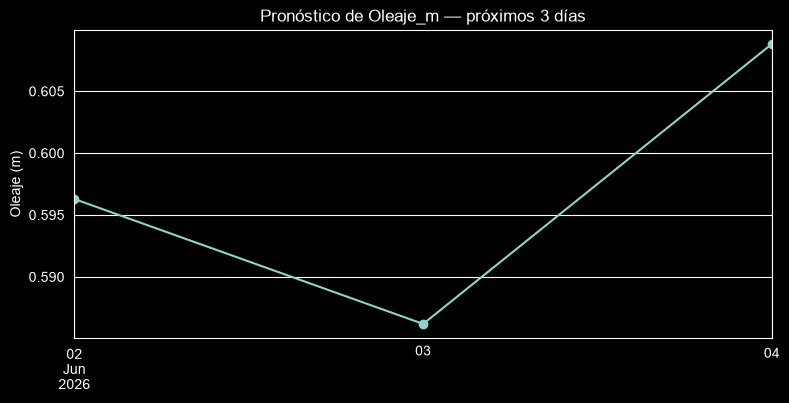

2026-06-02    0.596288
2026-06-03    0.586191
2026-06-04    0.608827
Freq: D, Name: Oleaje_m_pred, dtype: float64

In [9]:
data_oleaje = df[features].values
target_idx = features.index("Oleaje_m")

full_scaled = scaler_oleaje.transform(data_oleaje)
ultima_ventana = full_scaled[-30:]
ultima_ventana = np.expand_dims(ultima_ventana, axis=0)

pred_scaled = modelo_oleaje.predict(ultima_ventana, verbose=0)
pred_final = rnn.desescalar_target(pred_scaled, scaler_oleaje, target_idx, len(features))[0]

pred_index = pd.date_range(df.index[-1], periods=4, freq="D")[1:]
pred_series = pd.Series(pred_final, index=pred_index, name="Oleaje_m_pred")

plt.figure(figsize=(9, 4))
pred_series.plot(marker='o', title="Pronóstico de Oleaje_m — próximos 3 días")
plt.ylabel("Oleaje (m)")
plt.show()

pred_series


## 6. Entrenar los otros 2 modelos

 Como`rnn.entrenar()` ya recibe `target` como parámetro, se entrenan los
3 modelos con un simple loop.


In [11]:
resultados = {"Oleaje_m": metricas_oleaje}

for target in ["Marea_m", "SST_Copernicus"]:
    if target not in features:
        print(f"[aviso] '{target}' no está disponible en el dataset — se omite.")
        continue
    _, _, metricas = rnn.entrenar(target=target)
    resultados[target] = metricas


=== Entrenando modelo LSTM — target: Marea_m ===

Train: 380 secuencias | Test: 71 secuencias


C:\Users\estef\OneDrive\Documentos\IICuatrimestre-2026\Proyecto_II\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 100)        │        44,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,753 (292.00 KB)

...

 Trainable params: 74,753 (292.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.0976 - mae: 0.2402 - val_loss: 0.0292 - val_mae: 0.1159
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0212 - mae: 0.1164 - val_loss: 0.0362 - val_mae: 0.1338
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0145 - mae: 0.0972 - val_loss: 0.0248 - val_mae: 0.1021
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0130 - mae: 0.0897 - val_loss: 0.0238 - val_mae: 0.0980
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0120 - mae: 0.0861 - val_loss: 0.0290 - val_mae: 0.1129
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0113 - mae: 0.0833 - val_loss: 0.0313 - val_mae: 0.1196
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0107 - mae: 0.0817 - val_loss: 0.0231 - val_mae: 0.0978
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0113 - mae: 0.0806 - val_loss: 0.0213 - val_mae: 0.0937
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - lo

C:\Users\estef\OneDrive\Documentos\IICuatrimestre-2026\Proyecto_II\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0676 - mae: 0.1986
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0208 - mae: 0.1107
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0155 - mae: 0.0977
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0154 - mae: 0.0977
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0144 - mae: 0.0943
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0135 - mae: 0.0912
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0119 - mae: 0.0862
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0120 - mae: 0.0853
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0114 - mae: 0.0839
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0101 - mae: 0.0798
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0111 - mae: 0.0818
Epoch 12/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0101 - mae: 0.0782
Epoch 13/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/s

## 7. Tabla comparativa de resultados

Esta es la sección de resultados del informe técnico: RMSE y MAE de cada modelo

In [12]:
tabla = pd.DataFrame(resultados).T
tabla["mejora_rmse_%"] = (1 - tabla["rmse"] / tabla["rmse_baseline"]) * 100
tabla = tabla.round(3)
tabla


,rmse,mae,rmse_baseline,mae_baseline,mejora_rmse_%
Oleaje_m,0.104,0.083,0.093,0.068,-11.272
Marea_m,0.074,0.062,0.035,0.027,-111.475
SST_Copernicus,0.262,0.214,0.222,0.177,-17.914


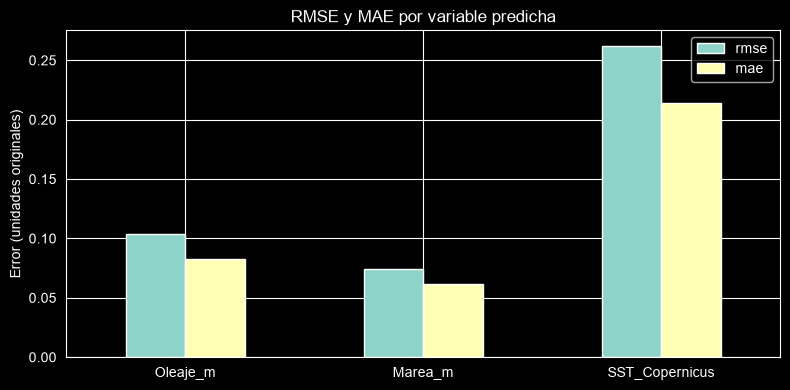

In [13]:
tabla[["rmse", "mae"]].plot(kind="bar", figsize=(8, 4), title="RMSE y MAE por variable predicha")
plt.ylabel("Error (unidades originales)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
